
# Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Nota_CM_piano.mp3 to Nota_CM_piano.mp3


In [15]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate, integrate
import pandas as pd

In [6]:
pip install librosa

In [12]:
# Cargar audio (como hizo el profe)
y, sr = librosa.load("Nota_CM_piano.mp3", sr=None)
print("Frecuencia de muestreo:", sr)
print("Número de muestras:", len(y))

Frecuencia de muestreo: 44100
Número de muestras: 152064


**Transformada con Scipy y Numpy**

In [11]:
t = np.arange(len(y)) / sr #tiempo (1/frecuencia)
Y = np.fft.fft(y) #Transformada de fourier de la señal
freq = np.fft.fftfreq(len(y), d=1/sr) #Frecuencias asociadas
amp = np.abs(Y)

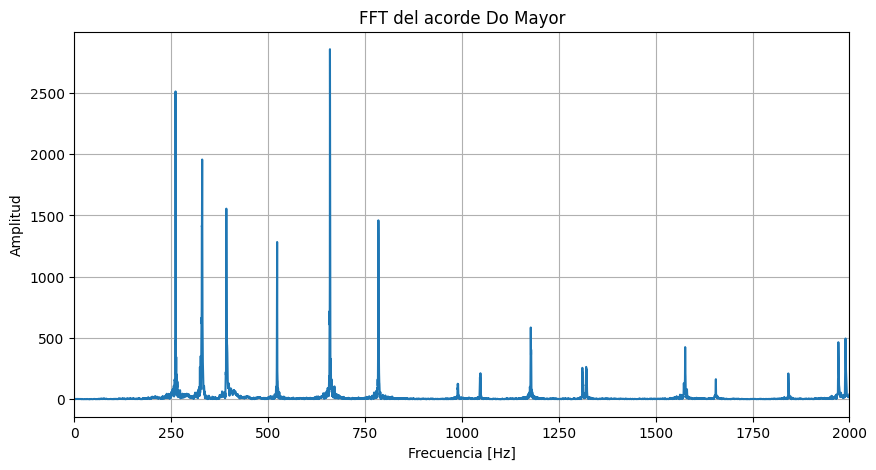

In [13]:
#Graficando ando
mask = freq > 0 #las frecuencias tienen sentido fisico si son positivas

plt.figure(figsize=(10,5))
plt.plot(freq[mask], amp[mask])
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("FFT del acorde Do Mayor")
plt.xlim(0,2000)
plt.grid()
plt.show()

**Transformada con la función proveída**

In [16]:
#Funcion para la transformada que nos regalo el profe
def FT(x,y):

    # Interpolación
    f_interp = interpolate.interp1d(
        x, y,
        kind='cubic',
        fill_value='extrapolate'
    )

    ft = lambda t: f_interp(t)

    # Frecuencias en Hz
    f = np.linspace(20, 2000, 500)

    df = []

    for fi in f:

        # frecuencia angular
        w = 2*np.pi*fi

        ARew = integrate.quad(
            lambda t: np.real(ft(t)*np.exp(-1j*w*t)),
            x.min(),
            x.max()
        )[0]

        AImw = integrate.quad(
            lambda t: np.imag(ft(t)*np.exp(-1j*w*t)),
            x.min(),
            x.max()
        )[0]

        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)

        df.append([fi, ARew, AImw, AMP, ANG])

    df = pd.DataFrame(
        df,
        columns=['f','ReTw','ImTw','AMP','ANG']
    )

    return df

In [17]:
df = FT(t,y) # la paciencia es virtud de sabios

/tmp/ipykernel_6383/3064772735.py:23: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  ARew = integrate.quad(
/tmp/ipykernel_6383/3064772735.py:29: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(
/tmp/ipykernel_6383/3064772735.py:23: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(
/tmp/ipykernel_6383/3064772735.py:29: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the i

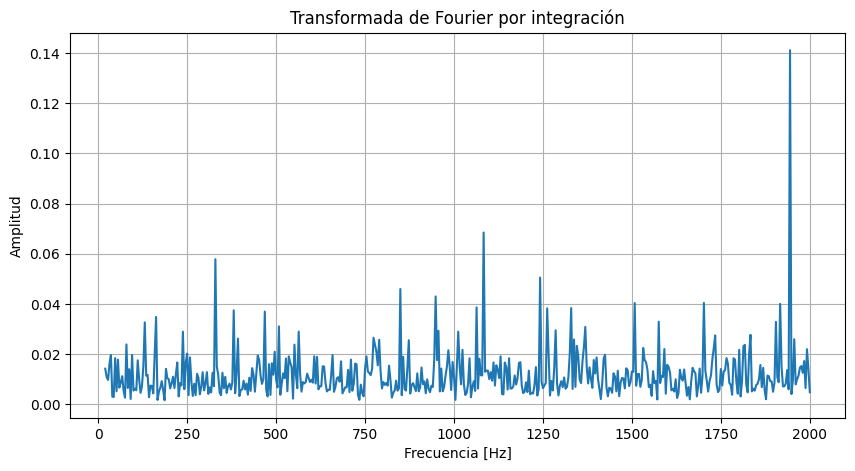

In [18]:
#Graficando ando
plt.figure(figsize=(10,5))
plt.plot(df['f'], df['AMP'])
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier Manual")
plt.grid()
plt.show()

# **Comparación de los resultados**

En ambas se pueden apreciar las frecuencias fundamentales (y sus armónicos) de la escala, como es de esperarse, salvo que se pronuncian mucho mejor en la transformada de numpy, que es computacionalmente mucho más eficiente y no tiene el mismo ruido de fondo, que se aprecia en su equivalente de la rutina que realiza directamente la integración numérica. Ambas son consistentes con la definición de transformada de Fourier.